# **EDA проекта: Прогнозирование выхода сборной в четвертьфинал чемпионата мира**

В проекте исследуется датасет, содержащий характеристики национальных футбольных сборных перед чемпионатами мира 2006–2022 годов, а также аналогичные признаки для турнира 2026 года.

Цель анализа — изучить, какие факторы связаны с успешным выступлением команды, и построить модель бинарной классификации, предсказывающую, выйдет ли сборная в четвертьфинал чемпионата мира.

Целевая переменная — `quarter_finalist`:
- `1` — команда вышла в четвертьфинал;
- `0` — команда не вышла в четвертьфинал.

# **1. Импорт библиотек и загрузка данных**

In [27]:
import pandas as pd
import numpy as np
import kagglehub

path = kagglehub.dataset_download(
    "harrachimustapha/fifa-world-cup-team-dataset"
)

print(path)
print(os.listdir(path))

100%|██████████| 7.16k/7.16k [00:00<00:00, 8.33MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/harrachimustapha/fifa-world-cup-team-dataset/versions/1
['test.csv', 'train.csv']


# **2. Загрузка данных в переменные и просмотр их формата**

In [34]:
import os

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nTrain columns:\n{list(train.columns)}")
print(f"\nQuarter-finalist distribution:\n{train[target].value_counts()}")
print(f"\nQuarter-finalist share: {train[target].mean():.3f}")



Train shape: (192, 24)
Test shape:  (48, 24)

Train columns:
['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before', 'winner', 'finalist', 'semi_finalist', 'quarter_finalist']

Quarter-finalist distribution:
quarter_finalist
0    144
1     48
Name: count, dtype: int64

Quarter-finalist share: 0.250


In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    object 
 2   continent                        192 non-null    object 
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 non-null    int64  
 12  fifa_points_pre_tourna

# **3. Описание признаков**

Все переменные датасета можно разделить на несколько смысловых групп.

**Категориальные признаки:**
- `team` — название национальной сборной;
- `continent` — континент команды.

**Временной признак:**
- `version` — год чемпионата мира.

**Бинарный предтурнирный признак:**
- `is_host` — является ли сборная хозяином турнира.

**Показатели формы команды за последние 4 года:**
- `goals_scored_last_4y`;
- `goals_received_last_4y`;
- `wins_last_4y`;
- `losses_last_4y`;
- `draws_last_4y`.

**Показатели текущей силы состава перед турниром:**
- `squad_total_market_value_eur`;
- `fifa_rank_pre_tournament`;
- `fifa_points_pre_tournament`;
- `squad_avg_age`.

**Исторический опыт выступлений на чемпионатах мира:**
- `world_cup_titles_before`;
- `world_cup_participations_before`;
- `groups_passed_before`;
- `round16_before`;
- `quarterfinals_before`;
- `semifinals_before`;
- `finals_before`.

**Итоговые результаты турнира:**
- `winner`;
- `finalist`;
- `semi_finalist`;
- `quarter_finalist`.

В дальнейшем целевой переменной будет `quarter_finalist`.
Признаки `winner`, `finalist`, `semi_finalist` не будут использоваться
при построении модели, поскольку они описывают результаты того же турнира
и создают утечку целевой информации.

In [35]:
train['version'].value_counts().sort_index()


,count
version,
2002,32
2006,32
2010,32
2014,32
2018,32
2022,32


#  Структура обучающей выборки

Обучающая выборка содержит 192 наблюдения. Каждая строка соответствует одной национальной сборной на конкретном чемпионате мира.

В выборке представлены шесть турниров:
- 2002,
- 2006,
- 2010,
- 2014,
- 2018,
- 2022.

Для каждого турнира содержится по 32 команды, что соответствует формату чемпионатов мира этих лет.

Тестовая выборка содержит команды чемпионата мира 2026 года, для которых требуется построить прогноз.

In [36]:
train.isna().sum()[train.isna().sum() > 0]

,0
squad_total_market_value_eur,32


In [37]:
train[train['squad_total_market_value_eur'].isna()]['version'].value_counts().sort_index()

,count
version,
2002,32


In [38]:
test['version'].value_counts().sort_index()

,count
version,
2026,48


## Пропущенные значения

В обучающей выборке пропуски обнаружены только в признаке
`squad_total_market_value_eur` — суммарной рыночной стоимости состава.

Всего отсутствует 32 значения. Проверка показала, что все они относятся
к чемпионату мира 2002 года. Следовательно, пропуски имеют не случайный,
а систематический характер: данные о рыночной стоимости составов для этого
турнира в датасете отсутствуют полностью.

На этапе разведочного анализа пропуски сохраняются.
Способ их обработки будет выбран позднее перед построением модели.

# **4. Анализ)**

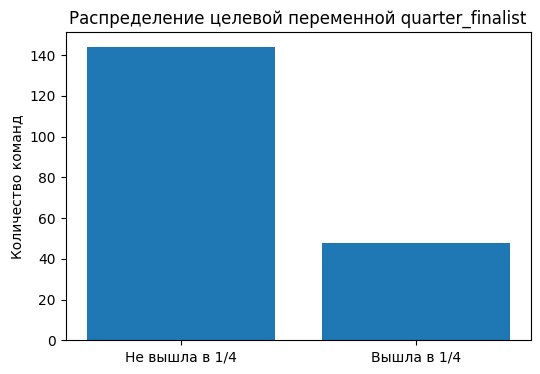

In [41]:
import matplotlib.pyplot as plt

target_counts = train['quarter_finalist'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Не вышла в 1/4', 'Вышла в 1/4'], target_counts.values)
plt.title('Распределение целевой переменной quarter_finalist')
plt.ylabel('Количество команд')
plt.show()

Целевая переменная имеет умеренный дисбаланс классов:
четвертьфиналистами являются 48 команд из 192, то есть 25% выборки.
Такое соотношение соответствует структуре чемпионата мира,
где в четвертьфинал выходят 8 из 32 участников.

При построении модели необходимо учитывать этот дисбаланс:
простая метрика accuracy может быть недостаточно информативной.

### **Анализ по континентам**

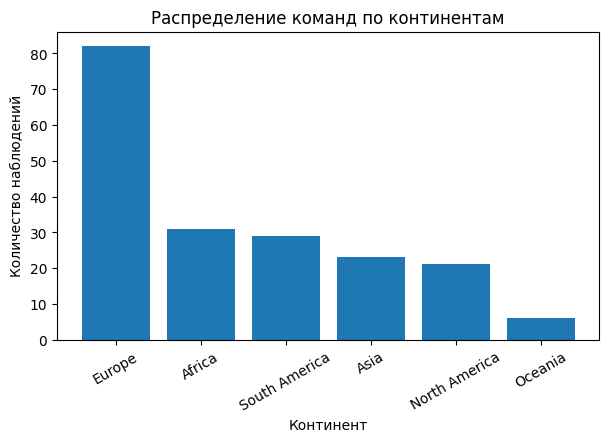

In [42]:
continent_counts = train['continent'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(continent_counts.index, continent_counts.values)
plt.title('Распределение команд по континентам')
plt.xlabel('Континент')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=30)
plt.show()

In [43]:
continent_qf_rate = (
    train.groupby('continent')['quarter_finalist']
    .mean()
    .sort_values(ascending=False)
)

continent_qf_rate

,quarter_finalist
continent,
South America,0.482759
Europe,0.341463
Africa,0.096774
North America,0.095238
Asia,0.043478
Oceania,0.000000


Наибольшее число наблюдений в датасете приходится на европейские сборные.
Это связано с высокой представленностью Европы на чемпионатах мира.

Однако если рассматривать не абсолютное количество команд, а долю сборных,
которым удалось выйти в четвертьфинал, лидером оказывается Южная Америка:
примерно 48% южноамериканских команд в выборке доходили до стадии 1/4 финала.
Для Европы этот показатель составляет около 34%.

У команд из Африки, Северной Америки и Азии доля выходов в четвертьфинал
существенно ниже. Для Океании она равна нулю, однако этот результат следует
интерпретировать осторожно из-за малого числа наблюдений по данному региону.

**Анализ сил команд**

In [45]:
strength_features = [
    'fifa_rank_pre_tournament',
    'fifa_points_pre_tournament',
    'squad_total_market_value_eur'
]
train.groupby('quarter_finalist')[strength_features].agg(['mean', 'median'])

fifa_rank_pre_tournament        fifa_points_pre_tournament  \
                                     mean median                       mean   
quarter_finalist                                                              
0                               26.763889   23.0                 918.723125   
1                               13.875000    9.5                1060.492500   

                        squad_total_market_value_eur               
                 median                         mean       median  
quarter_finalist                                                   
0                 780.5                 2.430242e+08  165140000.0  
1                 963.0                 6.441488e+08  616225000.0

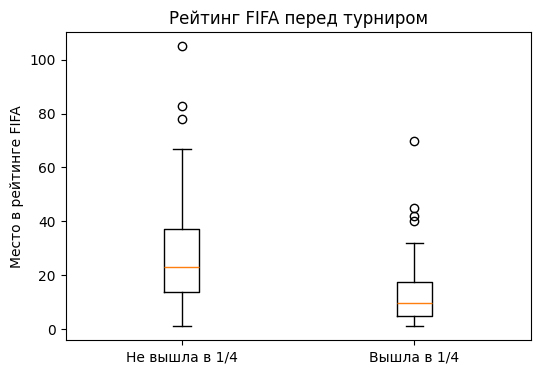

In [47]:
qf_0 = train.loc[train['quarter_finalist'] == 0, 'fifa_rank_pre_tournament']
qf_1 = train.loc[train['quarter_finalist'] == 1, 'fifa_rank_pre_tournament']

plt.figure(figsize=(6, 4))
plt.boxplot([qf_0, qf_1], tick_labels=['Не вышла в 1/4', 'Вышла в 1/4'])
plt.title('Рейтинг FIFA перед турниром')
plt.ylabel('Место в рейтинге FIFA')
plt.show()

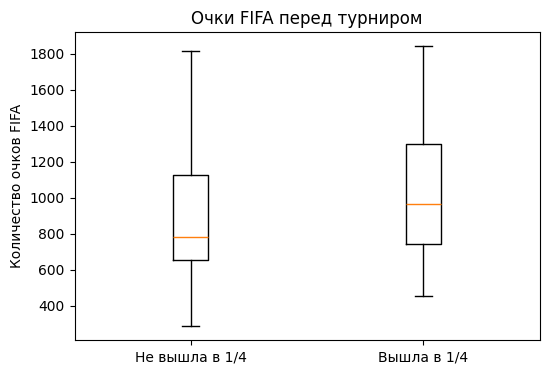

In [48]:
qf_0 = train.loc[train['quarter_finalist'] == 0, 'fifa_points_pre_tournament']
qf_1 = train.loc[train['quarter_finalist'] == 1, 'fifa_points_pre_tournament']

plt.figure(figsize=(6, 4))
plt.boxplot(
    [qf_0, qf_1],
    tick_labels=['Не вышла в 1/4', 'Вышла в 1/4']
)
plt.title('Очки FIFA перед турниром')
plt.ylabel('Количество очков FIFA')
plt.show()

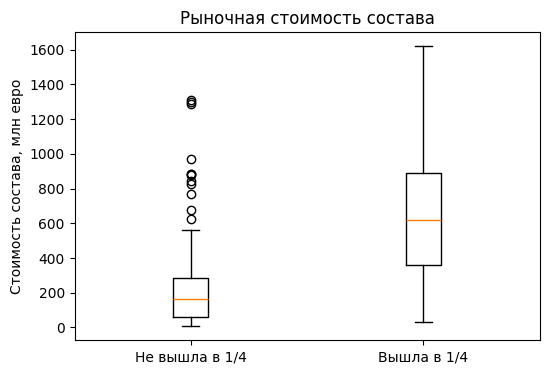

In [49]:
qf_0 = train.loc[
    train['quarter_finalist'] == 0,
    'squad_total_market_value_eur'
] / 1_000_000

qf_1 = train.loc[
    train['quarter_finalist'] == 1,
    'squad_total_market_value_eur'
] / 1_000_000

plt.figure(figsize=(6, 4))
plt.boxplot(
    [qf_0.dropna(), qf_1.dropna()],
    tick_labels=['Не вышла в 1/4', 'Вышла в 1/4']
)
plt.title('Рыночная стоимость состава')
plt.ylabel('Стоимость состава, млн евро')
plt.show()

В целом более высокий рейтинг FIFA, большее число рейтинговых очков и высокая стоимость состава связаны с большей вероятностью выхода в четвертьфинал. Однако ни один из этих признаков не является решающим сам по себе: распределения групп заметно пересекаются, среди нечетвертьфиналистов встречаются команды с сильным рейтингом и дорогим составом, а отдельные сборные с относительно скромными показателями всё же проходили в 1/4 финала. Поэтому успешность команды разумнее рассматривать как результат сочетания нескольких факторов, а не как следствие одного отдельного показателя.

**Анализ формы команд за последние 4 года**

In [50]:
form_features = [
    'goals_scored_last_4y',
    'goals_received_last_4y',
    'wins_last_4y',
    'losses_last_4y',
    'draws_last_4y'
]
train.groupby('quarter_finalist')[form_features].agg(['mean', 'median'])

goals_scored_last_4y        goals_received_last_4y         \
                                 mean median                   mean median   
quarter_finalist                                                             
0                           82.180556   80.5              45.708333   44.0   
1                           91.791667   95.0              41.166667   39.5   

                 wins_last_4y        losses_last_4y        draws_last_4y  \
                         mean median           mean median          mean   
quarter_finalist                                                           
0                   25.451389   24.0      11.701389   11.0     11.819444   
1                   27.833333   29.0       9.104167    8.0     11.750000   

                         
                 median  
quarter_finalist         
0                  12.0  
1                  11.0

Показатели формы за последние 4 года в целом смещены в пользу будущих четвертьфиналистов:
они чаще побеждали, больше забивали и реже проигрывали. Однако различия не выглядят
настолько выраженными, как для рейтинга FIFA или стоимости состава. Особенно слабо
разделяет группы число ничьих, значения которого почти совпадают.

Важно также учитывать, что эти признаки заданы в абсолютных количествах за 4 года.
Поэтому они могут отражать не только качество игры, но и различия в числе проведённых матчей.
Далее имеет смысл дополнительно рассмотреть производные показатели, например разницу голов
и долю побед.

In [52]:
train['goal_diff_last_4y'] = (
    train['goals_scored_last_4y'] - train['goals_received_last_4y']
)

train['matches_last_4y'] = (
    train['wins_last_4y']
    + train['losses_last_4y']
    + train['draws_last_4y']
)

train['win_rate_last_4y'] = (
    train['wins_last_4y'] / train['matches_last_4y']
)
test['goal_diff_last_4y'] = (
    test['goals_scored_last_4y'] - test['goals_received_last_4y']
)

test['matches_last_4y'] = (
    test['wins_last_4y']
    + test['losses_last_4y']
    + test['draws_last_4y']
)

test['win_rate_last_4y'] = (
    test['wins_last_4y'] / test['matches_last_4y']
)

Пронормируем количество матчей

In [53]:
for df in [train, test]:
    df['matches_last_4y'] = (
        df['wins_last_4y']
        + df['losses_last_4y']
        + df['draws_last_4y']
    )

    df['goal_diff_last_4y'] = (
        df['goals_scored_last_4y']
        - df['goals_received_last_4y']
    )

    df['win_rate_last_4y'] = (
        df['wins_last_4y'] / df['matches_last_4y']
    )

    df['goals_scored_per_match_last_4y'] = (
        df['goals_scored_last_4y'] / df['matches_last_4y']
    )

    df['goals_received_per_match_last_4y'] = (
        df['goals_received_last_4y'] / df['matches_last_4y']
    )

In [54]:
derived_form_features = [
    'matches_last_4y',
    'goal_diff_last_4y',
    'win_rate_last_4y',
    'goals_scored_per_match_last_4y',
    'goals_received_per_match_last_4y'
]

train.groupby('quarter_finalist')[derived_form_features].agg(['mean', 'median'])

matches_last_4y        goal_diff_last_4y         \
                            mean median              mean median   
quarter_finalist                                                   
0                      48.972222   48.0         36.472222   36.0   
1                      48.687500   49.0         50.625000   50.0   

                 win_rate_last_4y           goals_scored_per_match_last_4y  \
                             mean    median                           mean   
quarter_finalist                                                             
0                        0.518310  0.525870                       1.675909   
1                        0.571303  0.589397                       1.884749   

                           goals_received_per_match_last_4y            
                    median                             mean    median  
quarter_finalist                                                       
0                 1.636689                         0.933012  0.926650  
1                 1.940376                         0.846719  0.840278

После нормировки на количество проведённых матчей видно, что различия в форме команд
не сводятся к разному объёму игровой практики: четвертьфиналисты и остальные сборные
провели за 4 года примерно одинаковое число матчей.

При этом будущие четвертьфиналисты в среднем имели более высокую разницу забитых
и пропущенных мячей, чаще побеждали, больше забивали за матч и немного реже пропускали.
Следовательно, общая результативность и стабильность команды в предтурнирный период
могут быть полезными признаками для прогноза.

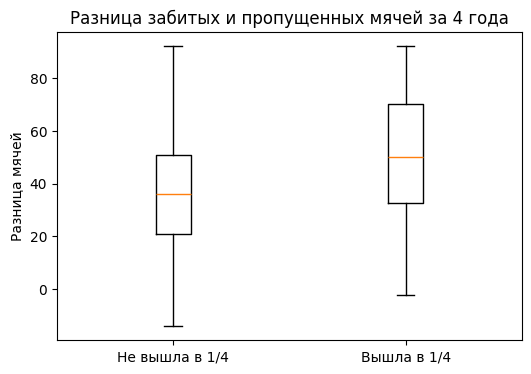

In [55]:
qf_0 = train.loc[train['quarter_finalist'] == 0, 'goal_diff_last_4y']
qf_1 = train.loc[train['quarter_finalist'] == 1, 'goal_diff_last_4y']

plt.figure(figsize=(6, 4))
plt.boxplot(
    [qf_0, qf_1],
    tick_labels=['Не вышла в 1/4', 'Вышла в 1/4']
)
plt.title('Разница забитых и пропущенных мячей за 4 года')
plt.ylabel('Разница мячей')
plt.show()

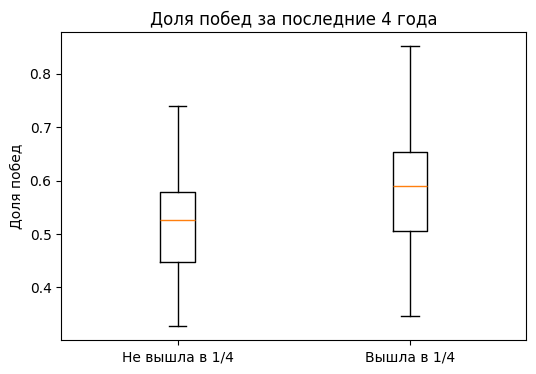

In [56]:
qf_0 = train.loc[train['quarter_finalist'] == 0, 'win_rate_last_4y']
qf_1 = train.loc[train['quarter_finalist'] == 1, 'win_rate_last_4y']

plt.figure(figsize=(6, 4))
plt.boxplot(
    [qf_0, qf_1],
    tick_labels=['Не вышла в 1/4', 'Вышла в 1/4']
)
plt.title('Доля побед за последние 4 года')
plt.ylabel('Доля побед')
plt.show()

Четвертьфиналисты в среднем имеют более высокую разницу забитых и пропущенных мячей,
а также большую долю побед за последние 4 года. При этом распределения групп
заметно пересекаются: команды с сопоставимой формой могли как выйти, так и не выйти
в 1/4 финала. Поэтому показатели текущей формы полезны для прогноза,
но не позволяют однозначно определить результат по отдельности.

**Корелляционный анализ**

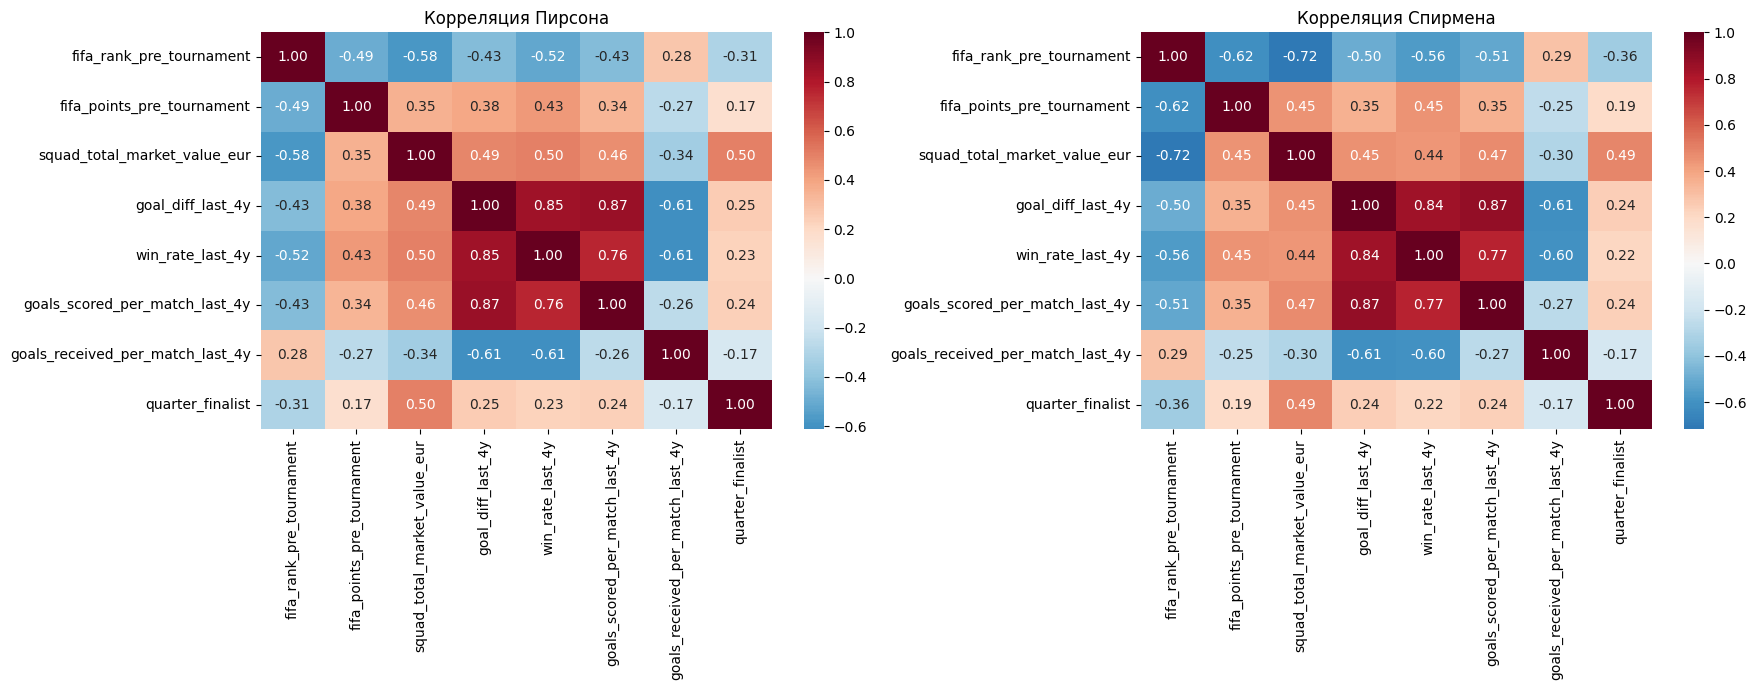

In [59]:
import seaborn as sns

corr_features = [
    'fifa_rank_pre_tournament',
    'fifa_points_pre_tournament',
    'squad_total_market_value_eur',
    'goal_diff_last_4y',
    'win_rate_last_4y',
    'goals_scored_per_match_last_4y',
    'goals_received_per_match_last_4y',
    'quarter_finalist'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    train[corr_features].corr(method='pearson'),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=axes[0]
)
axes[0].set_title('Корреляция Пирсона')

sns.heatmap(
    train[corr_features].corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=axes[1]
)
axes[1].set_title('Корреляция Спирмена')

plt.tight_layout()
plt.show()

Корреляционный анализ показывает, что из рассмотренных признаков наиболее заметно
с выходом в четвертьфинал связана рыночная стоимость состава. Также умеренная
отрицательная связь наблюдается для места в рейтинге FIFA: чем выше команда
в рейтинге, тем чаще она доходила до 1/4 финала.

Показатели текущей формы имеют более слабую связь с целевой переменной,
хотя направление этой связи соответствует ожиданиям. При этом между самими
признаками формы заметна сильная корреляция: разница мячей, доля побед
и результативность за матч частично описывают одно и то же качество команды.

Значения корреляций Пирсона и Спирмена в целом близки, поэтому найденные связи
не зависят существенно от выбора одного из этих двух коэффициентов.

# **5. Подготовка данных для построения моделей**

Из набора признаков были исключены:
- `quarter_finalist` — целевая переменная;
- `winner`, `finalist`, `semi_finalist` — итоговые результаты турнира, использование которых привело бы к утечке целевой информации;
- `team` — название сборной. На первом этапе этот признак не используется, чтобы модель опиралась на количественные характеристики команды, а не запоминала конкретные страны.

Разбиение выборки выполнено по времени:
- обучающая часть: чемпионаты мира 2002–2018 годов;
- валидационная часть: чемпионат мира 2022 года.

Такой подход ближе к реальной задаче, где модель обучается на прошлых турнирах и применяется к будущему.

Для числовых признаков пропуски заполняются медианой, после чего данные масштабируются.
Категориальный признак `continent` кодируется с помощью One-Hot Encoding.

In [60]:
target = 'quarter_finalist'

drop_columns = [
    'quarter_finalist',
    'winner',
    'finalist',
    'semi_finalist',
    'team'
]

X = train.drop(columns=drop_columns)
y = train[target]

In [61]:
train_mask = X['version'] < 2022
valid_mask = X['version'] == 2022

X_train = X[train_mask]
X_valid = X[valid_mask]

y_train = y[train_mask]
y_valid = y[valid_mask]

print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print()
print("Train target distribution:")
print(y_train.value_counts())
print()
print("Validation target distribution:")
print(y_valid.value_counts())

X_train shape: (160, 24)
X_valid shape: (32, 24)

Train target distribution:
quarter_finalist
0    120
1     40
Name: count, dtype: int64

Validation target distribution:
quarter_finalist
0    24
1     8
Name: count, dtype: int64


In [62]:
categorical_features = X_train.select_dtypes(include='object').columns.to_list()
numeric_features = X_train.select_dtypes(exclude='object').columns.to_list()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['continent']

Numeric features:
['version', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before', 'goal_diff_last_4y', 'matches_last_4y', 'win_rate_last_4y', 'goals_scored_per_match_last_4y', 'goals_received_per_match_last_4y']


**Обработка признаков**

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# **6. Построение моделей**

После подготовки признаков перейдём к построению моделей бинарной классификации.  

В качестве первой модели рассмотрим **логистическую регрессию**.

Обучение проводится на данных чемпионатов мира **2002–2018 годов**, а качество проверяется на турнире **2022 года**. Такое разбиение имитирует реальную задачу прогноза будущего чемпионата по информации о предыдущих турнирах.

Поскольку четвертьфиналисты составляют только 25% выборки, при обучении используется балансировка классов. Качество модели будем оценивать не только по accuracy, но и по precision, recall, F1-score и ROC-AUC.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_valid)
y_proba_logreg = logreg_model.predict_proba(X_valid)[:, 1]

In [65]:
print("Logistic Regression")
print(f"Accuracy:  {accuracy_score(y_valid, y_pred_logreg):.3f}")
print(f"Precision: {precision_score(y_valid, y_pred_logreg):.3f}")
print(f"Recall:    {recall_score(y_valid, y_pred_logreg):.3f}")
print(f"F1-score:  {f1_score(y_valid, y_pred_logreg):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_valid, y_proba_logreg):.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_valid, y_pred_logreg))

print("\nClassification report:")
print(classification_report(y_valid, y_pred_logreg))

Logistic Regression
Accuracy:  0.594
Precision: 0.353
Recall:    0.750
F1-score:  0.480
ROC-AUC:   0.818

Confusion matrix:
[[13 11]
 [ 2  6]]

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.54      0.67        24
           1       0.35      0.75      0.48         8

    accuracy                           0.59        32
   macro avg       0.61      0.65      0.57        32
weighted avg       0.74      0.59      0.62        32



Логистическая регрессия показала неоднозначный результат при стандартном пороге классификации 0.5.
Модель правильно определила 6 из 8 реальных четвертьфиналистов турнира 2022 года,
что соответствует recall 0.75. Однако одновременно она дала большое число ложноположительных
прогнозов, из-за чего precision оказался невысоким — 0.353.

При этом ROC-AUC равен 0.818, что указывает на достаточно хорошую способность модели
ранжировать команды по вероятности выхода в четвертьфинал. Поэтому в данной задаче
имеет смысл дополнительно оценивать не только бинарные прогнозы, но и качество
топ-8 команд с наибольшими предсказанными вероятностями.

In [66]:
valid_results = X_valid[['version']].copy()
valid_results['team'] = train.loc[valid_mask, 'team'].values
valid_results['actual_quarter_finalist'] = y_valid.values
valid_results['predicted_probability'] = y_proba_logreg

top_8_logreg = (
    valid_results
    .sort_values('predicted_probability', ascending=False)
    .head(8)
)

top_8_logreg

,version,team,actual_quarter_finalist,predicted_probability
67,2022,Brazil,1,0.989444
74,2022,England,1,0.963203
90,2022,Spain,0,0.955317
76,2022,Germany,0,0.949052
64,2022,Argentina,1,0.927664
84,2022,Portugal,1,0.903427
75,2022,France,1,0.897127
94,2022,Uruguay,0,0.848109


In [67]:
top_8_hits_logreg = top_8_logreg['actual_quarter_finalist'].sum()

print(f"Реальных четвертьфиналистов в топ-8 модели: {top_8_hits_logreg} из 8")

Реальных четвертьфиналистов в топ-8 модели: 5 из 8


Дополнительно была проведена оценка модели в формате, более близком к реальной турнирной задаче:
команды чемпионата мира 2022 года были отсортированы по предсказанной вероятности выхода
в четвертьфинал, после чего были выбраны 8 лидеров рейтинга.

Среди топ-8 команд, выделенных логистической регрессией, 5 действительно дошли до четвертьфинала.
Такой результат подтверждает вывод по ROC-AUC: несмотря на невысокую точность бинарной
классификации при фиксированном пороге 0.5, модель достаточно неплохо ранжирует сборные
по вероятности успешного выступления.



## Следующей моделью рассмотрим **Random Forest**



In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)
y_proba_rf = rf_model.predict_proba(X_valid)[:, 1]

In [69]:
print("Random Forest")
print(f"Accuracy:  {accuracy_score(y_valid, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_valid, y_pred_rf):.3f}")
print(f"Recall:    {recall_score(y_valid, y_pred_rf):.3f}")
print(f"F1-score:  {f1_score(y_valid, y_pred_rf):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_valid, y_proba_rf):.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_valid, y_pred_rf))

print("\nClassification report:")
print(classification_report(y_valid, y_pred_rf))

Random Forest
Accuracy:  0.781
Precision: 0.545
Recall:    0.750
F1-score:  0.632
ROC-AUC:   0.906

Confusion matrix:
[[19  5]
 [ 2  6]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84        24
           1       0.55      0.75      0.63         8

    accuracy                           0.78        32
   macro avg       0.73      0.77      0.74        32
weighted avg       0.81      0.78      0.79        32



Случайный лес показал более высокое качество, чем логистическая регрессия.
При одинаковом recall, равном 0.75, модель значительно сократила число ложноположительных
прогнозов: 5 против 11 у логистической регрессии. За счёт этого precision вырос
с 0.353 до 0.545, а F1-score — с 0.480 до 0.632.

Также повысился ROC-AUC: с 0.818 до 0.906. Это означает, что случайный лес лучше
ранжирует команды по вероятности выхода в четвертьфинал. Вероятно, преимущество модели
связано с её способностью учитывать нелинейные зависимости и взаимодействия между признаками.

In [70]:
valid_results_rf = X_valid[['version']].copy()
valid_results_rf['team'] = train.loc[valid_mask, 'team'].values
valid_results_rf['actual_quarter_finalist'] = y_valid.values
valid_results_rf['predicted_probability'] = y_proba_rf

top_8_rf = (
    valid_results_rf
    .sort_values('predicted_probability', ascending=False)
    .head(8)
)

top_8_rf

,version,team,actual_quarter_finalist,predicted_probability
67,2022,Brazil,1,0.849354
64,2022,Argentina,1,0.834822
75,2022,France,1,0.802343
74,2022,England,1,0.765291
90,2022,Spain,0,0.762662
82,2022,Netherlands,1,0.757434
76,2022,Germany,0,0.747427
66,2022,Belgium,0,0.745465


In [71]:
top_8_hits_rf = top_8_rf['actual_quarter_finalist'].sum()

print(f"Реальных четвертьфиналистов в топ-8 модели: {top_8_hits_rf} из 8")

Реальных четвертьфиналистов в топ-8 модели: 5 из 8


При ранжировании команд турнира 2022 года случайный лес, как и логистическая регрессия,
включил в топ-8 пять реальных четвертьфиналистов.

Однако по основным метрикам бинарной классификации Random Forest показал более высокое
качество: при том же recall он дал меньше ложноположительных прогнозов, а также получил
более высокие значения precision, F1-score и ROC-AUC.

Поэтому для построения итогового прогноза на чемпионат мира 2026 года в качестве основной
модели был выбран случайный лес.

# **7. Итоговый прогноз на чемпионат мира 2026 года**

Сравнение моделей показало, что случайный лес обеспечивает более устойчивое качество прогноза,
чем логистическая регрессия. Он лучше разделяет команды по вероятности выхода в четвертьфинал
и даёт меньше ложноположительных прогнозов на валидации по чемпионату мира 2022 года.

Поэтому на заключительном этапе случайный лес обучается уже на всей доступной истории
чемпионатов мира 2002–2022 годов. После этого модель применяется к тестовой выборке
с командами турнира 2026 года.

Для каждой сборной будет рассчитана вероятность выхода в четвертьфинал,
а итоговый прогноз будет представлен в виде восьми команд с наибольшими значениями этой вероятности.

In [72]:
X_full = train.drop(columns=drop_columns)
y_full = train[target]

X_test = test.drop(columns=drop_columns)

In [73]:
final_rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42
    ))
])

final_rf_model.fit(X_full, y_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['version', 'is_host',
                                                   'goals_scored_last_4y',
                                                   'goals_received_last_4y',
                                                   'wins_last_4y',
                                                   'losses_last_4y',
                                                   'draws_last_4y',
                                                   'world_cup_titles_before',
                                                   'squad_total_market_value_eur',
                                                   'fifa_rank_pre...
                                                   'finals_before',
                                                   'goal_diff_last_4y',
                                                   'matches_last_4y',
                                                   'win_rate_last_4y',
                                                   'goals_scored_per_match_last_4y',
                                                   'goals_received_per_match_last_4y']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['continent'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=3, n_estimators=300,
                                        random_state=42))])

In [74]:
test_proba_rf = final_rf_model.predict_proba(X_test)[:, 1]

world_cup_2026_predictions = test[['version', 'team', 'continent']].copy()
world_cup_2026_predictions['quarter_final_probability'] = test_proba_rf

world_cup_2026_predictions = (
    world_cup_2026_predictions
    .sort_values('quarter_final_probability', ascending=False)
)

world_cup_2026_predictions.head(15)

,version,team,continent,quarter_final_probability
2,2026,Argentina,South America,0.795747
3,2026,England,Europe,0.705382
0,2026,France,Europe,0.690490
1,2026,Spain,Europe,0.676319
6,2026,Netherlands,Europe,0.618923
7,2026,Morocco,Africa,0.614016
9,2026,Germany,Europe,0.611224
4,2026,Portugal,Europe,0.602830
12,2026,Senegal,Africa,0.543646
30,2026,Sweden,Europe,0.533440


In [75]:
predicted_top_8_2026 = world_cup_2026_predictions.head(8)

predicted_top_8_2026

,version,team,continent,quarter_final_probability
2,2026,Argentina,South America,0.795747
3,2026,England,Europe,0.705382
0,2026,France,Europe,0.690490
1,2026,Spain,Europe,0.676319
6,2026,Netherlands,Europe,0.618923
7,2026,Morocco,Africa,0.614016
9,2026,Germany,Europe,0.611224
4,2026,Portugal,Europe,0.602830


# **8. Прогноз четвертьфиналистов чемпионата мира 2026 года**

После обучения итоговой модели случайного леса на данных чемпионатов мира 2002–2022 годов
были рассчитаны модельные вероятности выхода в четвертьфинал для команд турнира 2026 года.

Наибольшие значения получили следующие сборные:

1. Argentina;
2. England;
3. France;
4. Spain;
5. Netherlands;
6. Morocco;
7. Germany;
8. Portugal.

Именно эти восемь команд модель выделяет как наиболее вероятных четвертьфиналистов чемпионата мира 2026 года.


# **9. Заключение**

В ходе проекта был проведён анализ данных о национальных сборных на чемпионатах мира 2002–2022 годов и построена модель для прогноза выхода команды в четвертьфинал турнира.

Разведочный анализ показал, что успешные команды в среднем отличаются более высоким рейтингом FIFA, большей рыночной стоимостью состава и лучшими показателями формы за предшествующие 4 года. При этом ни один признак не определяет результат однозначно: распределения групп заметно пересекаются, поэтому для прогноза требуется учитывать совокупность факторов.

Для решения задачи были обучены две модели — логистическая регрессия и случайный лес. Более качественные результаты на валидации по чемпионату мира 2022 года показал Random Forest: он получил ROC-AUC 0.906, F1-score 0.632 и верно включил 5 реальных четвертьфиналистов в топ-8 команд по предсказанной вероятности.

После обучения итоговой модели на всей исторической выборке был построен прогноз для чемпионата мира 2026 года. Наиболее вероятными четвертьфиналистами по версии модели стали Argentina, England, France, Spain, Netherlands, Morocco, Germany и Portugal.










Дэпаем?)